# Data Exploration

In [13]:
#pip install pandas numpy matplotlib openpyxl

In [1]:
#Call libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl as pxl
import re

#Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Import files df
path = "../Data/"
df_data = pd.read_excel(path + 'data.xlsx')
#df_operations = pd.read_excel(path + 'Dados Operações_ Localiza.xlsm', sheet_name='Export')
df_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 33481 entries, 0 to 33480
Data columns (total 43 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Criticidade              33480 non-null  str           
 1   Regional                 33479 non-null  str           
 2   Região                   33478 non-null  str           
 3   Filial                   33479 non-null  str           
 4   Agência                  33479 non-null  str           
 5   Tipo Filial              33479 non-null  str           
 6   Placa                    33479 non-null  str           
 7   Grupo                    33479 non-null  str           
 8   Fabricante               33479 non-null  str           
 9   Modelo                   33479 non-null  str           
 10  Sit. Anterior            33479 non-null  float64       
 11  Sit. Atual               33479 non-null  float64       
 12  Data Movimentação        33479 non-null  da

In [3]:
#Analyse data types of the columns in the DataFrames -> If necessary, change the data types of the columns to the correct ones with astypte() method
df_data.dtypes
df_data.head(5)

,Criticidade,Regional,Região,Filial,Agência,Tipo Filial,Placa,Grupo,Fabricante,Modelo,...,Previsão Ent.,Entrada,Envio Orc.,Aprovação Ult. Orc.,Previsão Peça,Previsão Conclusão,Data Conclusão,Tempo Desde Ult Monit.,Ultima Frase Usuário,Retorno Mon.
0,Sit. 35 - Atenção,NDE,NDE2,CONAT,CMNAT,RAC,RUG0F66,GX,JEEP,RENEGADE LONGITUDE,...,NaT,NaT,NaT,NaT,NaT,NaT,NaT,Sit. 35,NaN,NaN
1,Manut. - Caso Crítico,COE,COE6,COSRS,ACSRS,RAC,SHB0E09,CE,HYUNDAI,HB20 LIMITED 1.0,...,2023-02-02 20:19:18.343,2023-02-03 11:00:00,2023-07-24 10:23:16.143,2023-07-24 10:25:57.500,2023-08-28 16:30:00,NaT,NaT,T: __1 dias,Peça pendente - No prazo,Em 25/07/23 às 15h51: Peça pendente - No prazo...
2,Manut. - Caso Crítico,SPI,SPI5,CONAS,CMNAS,RAC,RUG9G77,P,GENERAL MOTORS,S10 CD LS 2.8,...,2023-02-08 20:40:54.380,2023-02-09 08:51:00,2023-07-24 17:14:13.720,2023-06-09 16:09:04.760,NaT,NaT,NaT,T: __0 dias,Aguardando aprovação de orçamento,Em 26/07/23 às 12h06: Aguardando aprovação de ...
3,Manut. - Caso Crítico,SPI,SPI3,COGTA,CMGTA,RAC,RVS3F45,LE,JEEP,COMPASS LONGITUDE,...,2023-03-30 10:39:22.650,2023-04-19 12:08:00,NaT,NaT,2023-07-18 13:11:00,2023-07-28 17:00:00,NaT,T: __0 dias,Acionar Montadora (Motivo observação),Em 26/07/23 às 12h27: Acionar Montadora (Motiv...
4,Manut. - Caso Crítico,COE,COE3,COCAV,CMCAV,RAC,RUD3F49,NX,FIAT,NOVA TORO FREEDOM,...,2023-01-24 16:16:21.770,2023-01-25 16:29:00,2023-07-21 14:09:24.637,2023-07-25 18:39:27.693,2023-07-28 17:00:00,NaT,NaT,T: __0 dias,Peça Pendente – Atrasada,Em 26/07/23 às 12h15: Peça Pendente – Atrasada...


In [7]:
#Data tratament
#Correction of the 'Faixa de KM' column to ensure that it is in the correct format for analysis range
df_data['Faixa de KM'] = df_data['Faixa de KM'].str.replace('01. De 0k a 10k', '01. De 00k a 10k').astype(str)

#New column 'Tempo Desde Ult Monit' in integer format to allow for analysis and convert NaN values to 0
df_data['Tempo Desde Ult Monit. Corrig. (Dias)'] = df_data['Tempo Desde Ult Monit.'].str.extract(r'(\d+)').astype(float).fillna(0).astype(int)

#Split on the " - " separator (only split on the first occurrence)
def split_status_date(value):
    if pd.isna(value):
        return pd.Series([None, pd.NaT])

    #Try to find a date pattern (dd/mm/yyyy hh:mm) anywhere in the string
    match = re.search(r'(\d{2}/\d{2}/\d{4}\s+\d{2}:\d{2})', value)

    if match:
        date_str = match.group(1)
        #Everything before the date (minus trailing " - " or spaces) is the status
        status = value[:match.start()].rstrip(' -').strip()
        date = pd.to_datetime(date_str, format='%d/%m/%Y %H:%M', errors='coerce')
    else:
        #No date found — whole string is the status, date is missing
        status = value.strip()
        date = pd.NaT

    return pd.Series([status, date])

df_data[['status corrig.', 'date actual']] = df_data['Status Atual (com data)'].apply(split_status_date)

#Remove hours and minutes from column 'Data Movimentação to keep only the date
df_data['Data Movimentação'] = pd.to_datetime(df_data['Data Movimentação'], format='%d/%m/%Y %H:%M', errors='coerce').dt.date
df_data

,Criticidade,Regional,Região,Filial,Agência,Tipo Filial,Placa,Grupo,Fabricante,Modelo,...,Aprovação Ult. Orc.,Previsão Peça,Previsão Conclusão,Data Conclusão,Tempo Desde Ult Monit.,Ultima Frase Usuário,Retorno Mon.,Tempo Desde Ult Monit. Corrig. (Dias),status corrig.,date actual
0,Sit. 35 - Atenção,NDE,NDE2,CONAT,CMNAT,RAC,RUG0F66,GX,JEEP,RENEGADE LONGITUDE,...,NaT,NaT,NaT,NaT,Sit. 35,NaN,NaN,35,AG. CONFERÊNCIA,NaT
1,Manut. - Caso Crítico,COE,COE6,COSRS,ACSRS,RAC,SHB0E09,CE,HYUNDAI,HB20 LIMITED 1.0,...,2023-07-24 10:25:57.500,2023-08-28 16:30:00,NaT,NaT,T: __1 dias,Peça pendente - No prazo,Em 25/07/23 às 15h51: Peça pendente - No prazo...,1,PENDENTE PEÇA (LL),2023-08-28 16:30:00
2,Manut. - Caso Crítico,SPI,SPI5,CONAS,CMNAS,RAC,RUG9G77,P,GENERAL MOTORS,S10 CD LS 2.8,...,2023-06-09 16:09:04.760,NaT,NaT,NaT,T: __0 dias,Aguardando aprovação de orçamento,Em 26/07/23 às 12h06: Aguardando aprovação de ...,0,PEND. ORÇAMENTO/DIAGNÓSTICO,NaT
3,Manut. - Caso Crítico,SPI,SPI3,COGTA,CMGTA,RAC,RVS3F45,LE,JEEP,COMPASS LONGITUDE,...,NaT,2023-07-18 13:11:00,2023-07-28 17:00:00,NaT,T: __0 dias,Acionar Montadora (Motivo observação),Em 26/07/23 às 12h27: Acionar Montadora (Motiv...,0,EM SERVIÇO,2023-07-28 17:00:00
4,Manut. - Caso Crítico,COE,COE3,COCAV,CMCAV,RAC,RUD3F49,NX,FIAT,NOVA TORO FREEDOM,...,2023-07-25 18:39:27.693,2023-07-28 17:00:00,NaT,NaT,T: __0 dias,Peça Pendente – Atrasada,Em 26/07/23 às 12h15: Peça Pendente – Atrasada...,0,PENDENTE PEÇA (LL),2023-07-28 17:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33476,Manut. Abaixo 30d,NDE,NDE3,COFOR,AMFOR,RAC,SHZ0F25,GK,RENAULT,DUSTER INTENSE 1.6,...,NaT,NaT,NaT,NaT,Sem Monit.,NaN,NaN,0,AG. AGENDAMENTO,NaT
33477,Manut. Abaixo 30d,SPA,SPA5,COZTI,CMZTI,ZARP,RUZ8G31,CS,HYUNDAI,HB20S COMFORT,...,NaT,NaT,2023-07-27 08:00:00,NaT,Sem Monit.,NaN,NaN,0,PENDENTE - SITUAÇÃO 87,NaT
33478,Manut. Abaixo 30d,SPI,SPI4,COSOR,CMSOR,RAC,RVE4A47,GK,VOLKSWAGEN,NIVUS COMFORTLINE,...,NaT,NaT,2023-07-27 08:00:00,NaT,Sem Monit.,NaN,NaN,0,PENDENTE - SITUAÇÃO 87,NaT
33479,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaT,NaT,NaT,NaT,NaN,NaN,NaN,0,NaN,NaT


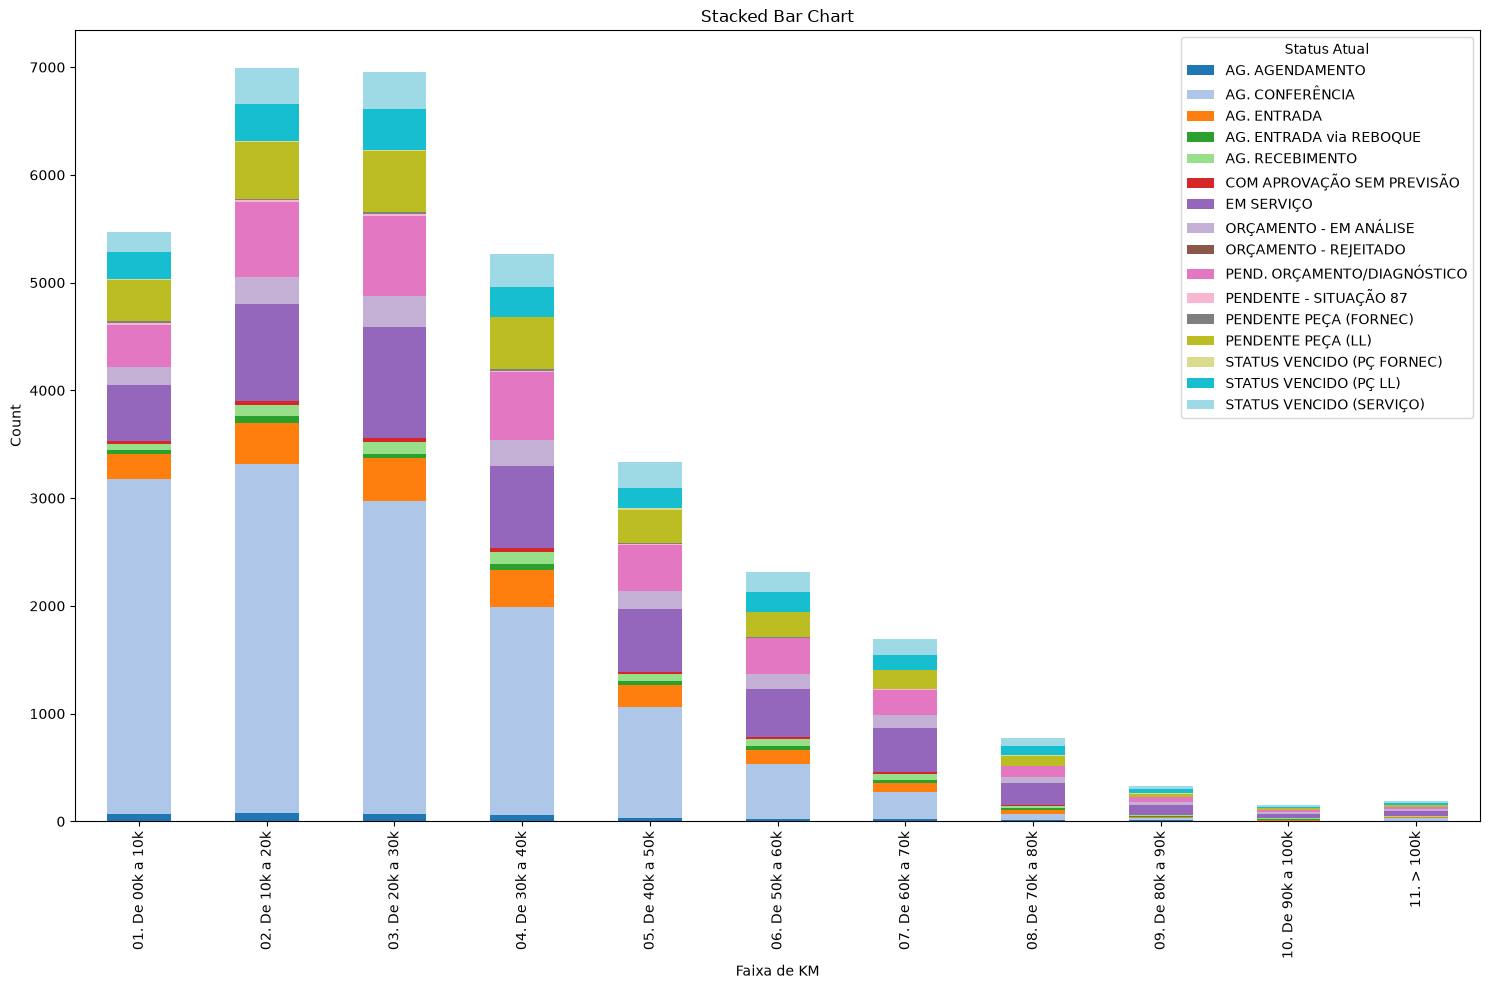

In [ ]:
#Analyse the 'Faixa de KM' column and the 'Status Atual' column to check for unique values and descriptive statistics
df_data['Faixa de KM'].describe()
df_data['Faixa de KM'].unique()
df_data['Status Atual'].describe()
df_data['Status Atual'].unique()
ct = pd.crosstab(df_data['Faixa de KM'], df_data['Status Atual'])

ct.plot(kind='bar', stacked=True, figsize=(15, 10), colormap='tab20')
plt.xlabel('Faixa de KM')
plt.ylabel('Count')
plt.title('Stacked Bar Chart')
plt.legend(title='Status Atual')
plt.tight_layout()
plt.show()

In [ ]:
#Group by and count the number of occurrences of each combination and crate a new DataFrame with the results
df_data_grouped = df_data.groupby(['Faixa de KM', 'Data Movimentação','status corrig.']).size().unstack().replace(np.nan, 0).reset_index()
cols_to_sum = df_data_grouped.columns.difference(['Faixa de KM', 'Data Movimentação','status corrig.'])
df_data_grouped["Total"] = df_data_grouped[cols_to_sum].sum(axis=1)
df_data_grouped = df_data_grouped.sort_values(by="Total", ascending=False).reset_index()
df_data_grouped.drop(columns=["index"], inplace=True)

#Create PK column to join with the df_data_grouped_time DataFrame
cols = ['Faixa de KM', 'Data Movimentação']
df_data_grouped['PK'] = df_data_grouped[cols].astype(str).apply('-'.join, axis=1)
df_data_grouped

status corrig.,Faixa de KM,Data Movimentação,AG. AGENDAMENTO,AG. CONFERÊNCIA,AG. ENTRADA,AG. ENTRADA via REBOQUE,AG. RECEBIMENTO,COM APROVAÇÃO SEM PREVISÃO,EM SERVIÇO,ORÇAMENTO - EM ANÁLISE,ORÇAMENTO - REJEITADO,PEND. ORÇAMENTO/DIAGNÓSTICO,PENDENTE - SITUAÇÃO 87,PENDENTE PEÇA (FORNEC),PENDENTE PEÇA (LL),STATUS VENCIDO (PÇ FORNEC),STATUS VENCIDO (PÇ LL),STATUS VENCIDO (SERVIÇO),Total,PK
0,02. De 10k a 20k,2023-07-26,50.0,1289.0,159.0,16.0,6.0,0.0,41.0,15.0,0.0,108.0,1.0,0.0,1.0,0.0,1.0,0.0,1687.0,02. De 10k a 20k-2023-07-26
1,03. De 20k a 30k,2023-07-26,40.0,1163.0,159.0,10.0,11.0,0.0,54.0,19.0,0.0,131.0,6.0,0.0,0.0,0.0,0.0,0.0,1593.0,03. De 20k a 30k-2023-07-26
2,01. De 00k a 10k,2023-07-26,25.0,1218.0,64.0,6.0,4.0,0.0,10.0,6.0,0.0,35.0,1.0,0.0,10.0,0.0,0.0,0.0,1379.0,01. De 00k a 10k-2023-07-26
3,02. De 10k a 20k,2023-07-25,14.0,827.0,94.0,21.0,21.0,0.0,118.0,49.0,0.0,133.0,8.0,0.0,18.0,0.0,1.0,20.0,1324.0,02. De 10k a 20k-2023-07-25
4,03. De 20k a 30k,2023-07-25,13.0,744.0,102.0,12.0,19.0,1.0,148.0,56.0,0.0,187.0,2.0,0.0,22.0,0.0,0.0,18.0,1324.0,03. De 20k a 30k-2023-07-25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
889,01. De 00k a 10k,2023-03-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,01. De 00k a 10k-2023-03-04
890,01. De 00k a 10k,2023-03-03,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,01. De 00k a 10k-2023-03-03
891,01. De 00k a 10k,2023-02-23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,01. De 00k a 10k-2023-02-23
892,01. De 00k a 10k,2023-02-14,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,01. De 00k a 10k-2023-02-14


In [14]:
#New group by and aggregate the mean of the 'Tempo Desde Ult Monit. Corrig. (Dias)' and 'Tempo Sit. (Dias)' columns to create a new DataFrame with the results
df_data_grouped_time = df_data.groupby(['Faixa de KM', 'Data Movimentação','status corrig.']).agg({'Tempo Desde Ult Monit. Corrig. (Dias)': 'mean', 'Tempo Sit. (Dias)': 'mean'}).unstack().replace(np.nan, 0).reset_index()
cols = ['Faixa de KM', 'Data Movimentação']
df_data_grouped_time['PK'] = df_data_grouped_time[cols].astype(str).apply('-'.join, axis=1)

#Join the columns time columns to the df_data_grouped_crit DataFrame and drop the unnecessary columns
df_data_grouped_time.columns = ['_'.join(map(str, col)) for col in df_data_grouped_time.columns]
df_data_grouped_time.drop(columns=['Faixa de KM_', 'Data Movimentação_'], inplace=True)
df_data_grouped_time

,Tempo Desde Ult Monit. Corrig. (Dias)_AG. AGENDAMENTO,Tempo Desde Ult Monit. Corrig. (Dias)_AG. CONFERÊNCIA,Tempo Desde Ult Monit. Corrig. (Dias)_AG. ENTRADA,Tempo Desde Ult Monit. Corrig. (Dias)_AG. ENTRADA via REBOQUE,Tempo Desde Ult Monit. Corrig. (Dias)_AG. RECEBIMENTO,Tempo Desde Ult Monit. Corrig. (Dias)_COM APROVAÇÃO SEM PREVISÃO,Tempo Desde Ult Monit. Corrig. (Dias)_EM SERVIÇO,Tempo Desde Ult Monit. Corrig. (Dias)_ORÇAMENTO - EM ANÁLISE,Tempo Desde Ult Monit. Corrig. (Dias)_ORÇAMENTO - REJEITADO,Tempo Desde Ult Monit. Corrig. (Dias)_PEND. ORÇAMENTO/DIAGNÓSTICO,...,Tempo Sit. (Dias)_ORÇAMENTO - EM ANÁLISE,Tempo Sit. (Dias)_ORÇAMENTO - REJEITADO,Tempo Sit. (Dias)_PEND. ORÇAMENTO/DIAGNÓSTICO,Tempo Sit. (Dias)_PENDENTE - SITUAÇÃO 87,Tempo Sit. (Dias)_PENDENTE PEÇA (FORNEC),Tempo Sit. (Dias)_PENDENTE PEÇA (LL),Tempo Sit. (Dias)_STATUS VENCIDO (PÇ FORNEC),Tempo Sit. (Dias)_STATUS VENCIDO (PÇ LL),Tempo Sit. (Dias)_STATUS VENCIDO (SERVIÇO),PK_
0,0.0,35.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.00000,01. De 00k a 10k-2023-01-04
1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.00000,01. De 00k a 10k-2023-02-14
2,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.000000,0.0,0.0,152.765235,0.0,0.0,0.00000,01. De 00k a 10k-2023-02-23
3,0.0,0.0,0.0,0.0,0.0,0.0,2.000000,0.0,0.0,0.0,...,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.00000,01. De 00k a 10k-2023-02-25
4,0.0,0.0,0.0,0.0,0.0,0.0,7.000000,0.0,0.0,0.0,...,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.00000,01. De 00k a 10k-2023-03-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
889,0.0,35.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,2.0,...,4.131080,0.0,4.017550,0.0,0.0,4.091936,0.0,0.0,0.00000,11. > 100k-2023-07-22
890,0.0,35.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.00000,11. > 100k-2023-07-23
891,0.0,35.0,0.0,0.0,0.0,0.0,1.000000,1.5,0.0,3.0,...,1.951803,0.0,1.935472,0.0,0.0,2.110154,0.0,0.0,1.88954,11. > 100k-2023-07-24
892,0.0,35.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.8,...,0.848765,0.0,0.906068,0.0,0.0,0.000000,0.0,0.0,0.00000,11. > 100k-2023-07-25


In [15]:
#Merge the two DataFrames on the 'PK' column
df_data_grouped_final = pd.merge(df_data_grouped, df_data_grouped_time, left_on='PK', right_on='PK_', how='left')
df_data_grouped_final.drop(columns=['PK_'], inplace=True)
#Convert to excel file the final DataFrame
df_data_grouped_final.to_excel(path + 'data_grouped_final_second_hypothesis.xlsx', index=False)